## 0. Importaciones y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/fraud_oracle.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


---
# PARTE 1 — Modelos Matemáticos y Regresión
---

## 1.1 Exploración básica del dataset

Antes de construir cualquier modelo identificamos los **datos** (X), los **parámetros** (W) que queremos aprender, y el **error** que queremos minimizar.

In [2]:
print('=== Tipos de variables ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Distribución del target (FraudFound_P) ===')
print(df['FraudFound_P'].value_counts())
print(f"Tasa de fraude: {df['FraudFound_P'].mean():.2%}")

=== Tipos de variables ===
Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
PolicyNumber             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfCars            object
Year        

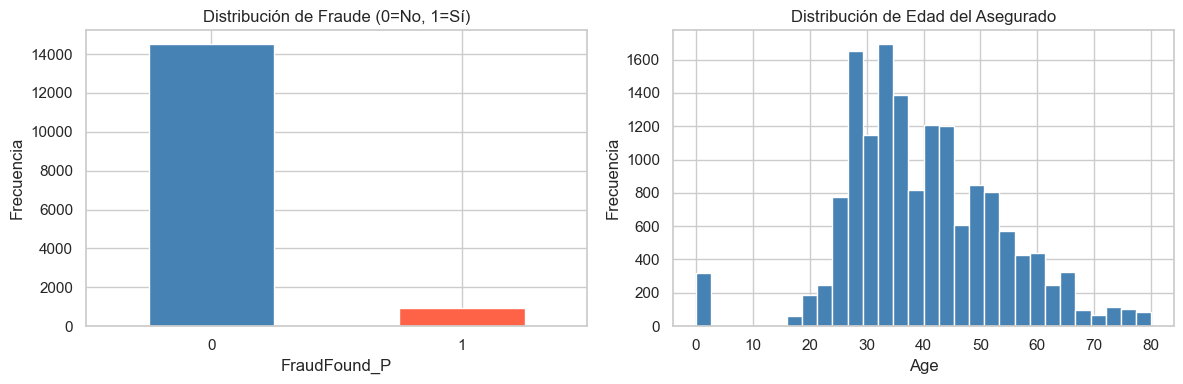

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del target
df['FraudFound_P'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de Fraude (0=No, 1=Sí)')
axes[0].set_xlabel('FraudFound_P')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Distribución de la edad
df['Age'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de Edad del Asegurado')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 1.2 Regresión Lineal — OLS sobre `Age` (caso real)

La **regresión lineal** modela la relación:

$$\hat{y} = X \cdot W = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

La solución analítica (**Ordinary Least Squares**) es:

$$W = (X^T X)^{-1} X^T Y$$

Aplicamos OLS intentando predecir `Age` a partir de variables numéricas del dataset. Este es el caso **real**: veremos que las features elegidas tienen poca capacidad predictiva sobre la edad, lo que se refleja en un R² bajo y el modelo prediciendo casi siempre la media.

=== Parámetros aprendidos (OLS sobre Age) ===
  bias (w0)                     : 31.3755
  WeekOfMonth                   : -0.0555
  WeekOfMonthClaimed            : 0.0322
  Deductible                    : 0.0213
  DriverRating                  : 0.0167
  RepNumber                     : -0.0209

R²   = 0.0049  ← casi 0: las features no explican la edad
RMSE = 13.46 años


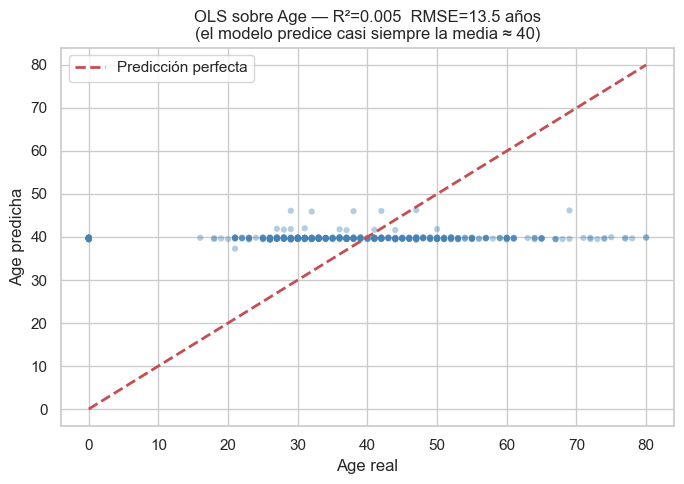

In [4]:
# --- Caso REAL: predecir Age ---
num_features = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating', 'RepNumber']
target_reg = 'Age'

X_reg = df[num_features].values
y_reg = df[target_reg].values

# Añadimos columna de unos para el término independiente (bias)
X_b = np.column_stack([np.ones(len(X_reg)), X_reg])

# OLS: W = (X^T X)^{-1} X^T Y  — solución analítica
W_ols = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_reg
y_pred_ols = X_b @ W_ols

ss_res = np.sum((y_reg - y_pred_ols) ** 2)
ss_tot = np.sum((y_reg - y_reg.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((y_reg - y_pred_ols) ** 2))

print('=== Parámetros aprendidos (OLS sobre Age) ===')
param_names = ['bias (w0)'] + num_features
for name, w in zip(param_names, W_ols):
    print(f'  {name:30s}: {w:.4f}')
print(f'\nR²   = {r2:.4f}  ← casi 0: las features no explican la edad')
print(f'RMSE = {rmse:.2f} años')

plt.figure(figsize=(7, 5))
plt.scatter(y_reg[:500], y_pred_ols[:500], alpha=0.4, color='steelblue', edgecolors='none', s=20)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Age real')
plt.ylabel('Age predicha')
plt.title(f'OLS sobre Age — R²={r2:.3f}  RMSE={rmse:.1f} años\n(el modelo predice casi siempre la media ≈ {y_reg.mean():.0f})')
plt.legend()
plt.tight_layout()
plt.show()

## 1.2b Regresión Lineal — OLS sobre `PrimaEstimada` (caso sintético ideal)

Ahora construimos una variable objetivo **sintética** con una relación lineal exacta conocida:

$$\text{Prima} = 500 + 80 \cdot \text{DriverRating} + 0.8 \cdot \text{Age} + 40 \cdot \widetilde{\text{Deductible}} + 60 \cdot \text{Fraud} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 30^2)$$

Como OLS es el estimador óptimo para este modelo, debe **recuperar exactamente los coeficientes reales** (salvo el ruido). El scatter real vs predicho seguirá la diagonal y el R² será próximo a 1.

Feature                  Real      OLS    Error
------------------------------------------------
bias (w0)              500.00   500.84     0.84
DriverRating            80.00    80.18     0.18
Age                      0.80     0.77     0.03
Deductible(z)           40.00    40.18     0.18
FraudFound_P            60.00    58.11     1.89

R²   = 0.9178  ← cercano a 1: OLS recupera la señal
RMSE = 30.05 €  (ruido introducido σ=30)


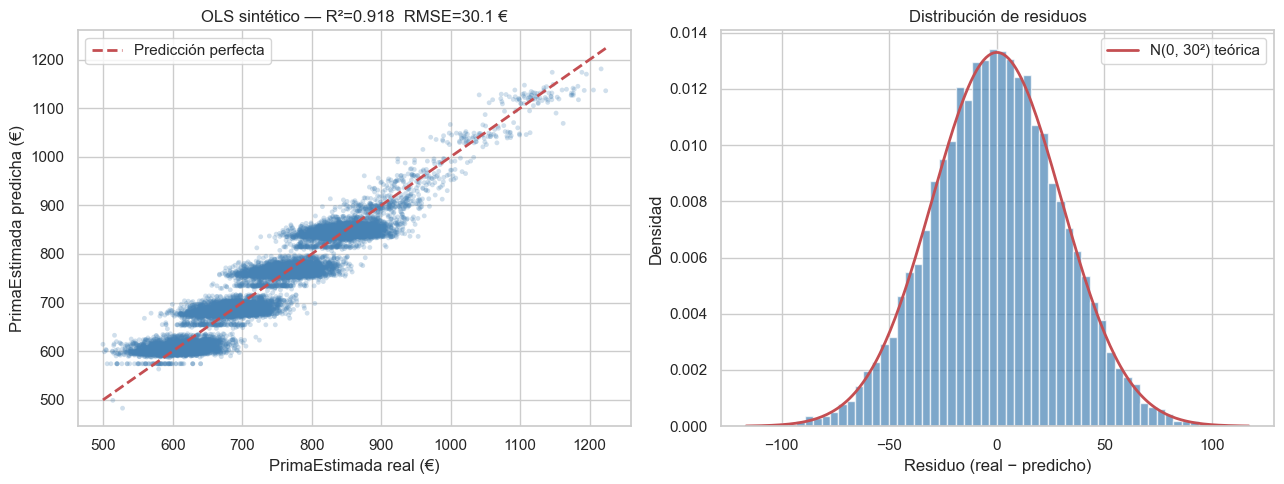

In [5]:
np.random.seed(42)

# Variables del dataset
driver_rating = df['DriverRating'].values          # 1–4
age_vals      = df['Age'].values                   # 16–80
deductible    = df['Deductible'].values            # 300–700
fraud_flag    = df['FraudFound_P'].values          # 0/1

# Normalizamos deductible (media 0, std 1) para que los coeficientes sean comparables
ded_norm = (deductible - deductible.mean()) / deductible.std()

# ── Coeficientes REALES (ground truth) ──
TRUE_BIAS   = 500
TRUE_DR     = 80
TRUE_AGE    = 0.8
TRUE_DED    = 40
TRUE_FRAUD  = 60
NOISE_STD   = 30

# Target sintético: relación lineal perfecta + ruido gaussiano
y_syn = (TRUE_BIAS
         + TRUE_DR    * driver_rating
         + TRUE_AGE   * age_vals
         + TRUE_DED   * ded_norm
         + TRUE_FRAUD * fraud_flag
         + np.random.normal(0, NOISE_STD, size=len(df)))

# Matrix de features (mismo orden que los coeficientes)
X_syn = np.column_stack([driver_rating, age_vals, ded_norm, fraud_flag])
X_syn_b = np.column_stack([np.ones(len(X_syn)), X_syn])

# OLS
W_syn = np.linalg.pinv(X_syn_b.T @ X_syn_b) @ X_syn_b.T @ y_syn
y_pred_syn = X_syn_b @ W_syn

mse_syn  = np.mean((y_syn - y_pred_syn) ** 2)
rmse_syn = np.sqrt(mse_syn)
r2_syn   = 1 - np.sum((y_syn - y_pred_syn)**2) / np.sum((y_syn - y_syn.mean())**2)

# ── Comparación coeficientes reales vs aprendidos ──
print(f'{"Feature":<20} {"Real":>8} {"OLS":>8} {"Error":>8}')
print('-' * 48)
coef_names  = ['bias (w0)', 'DriverRating', 'Age', 'Deductible(z)', 'FraudFound_P']
true_values = [TRUE_BIAS, TRUE_DR, TRUE_AGE, TRUE_DED, TRUE_FRAUD]
for name, true, learned in zip(coef_names, true_values, W_syn):
    print(f'{name:<20} {true:>8.2f} {learned:>8.2f} {abs(true-learned):>8.2f}')

print(f'\nR²   = {r2_syn:.4f}  ← cercano a 1: OLS recupera la señal')
print(f'RMSE = {rmse_syn:.2f} €  (ruido introducido σ={NOISE_STD})')

# ── Scatter real vs predicho ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot OLS sintético
axes[0].scatter(y_syn, y_pred_syn, alpha=0.25, color='steelblue', edgecolors='none', s=12)
mn, mx = y_syn.min(), y_syn.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('PrimaEstimada real (€)')
axes[0].set_ylabel('PrimaEstimada predicha (€)')
axes[0].set_title(f'OLS sintético — R²={r2_syn:.3f}  RMSE={rmse_syn:.1f} €')
axes[0].legend()

# Residuos: deben ser ~N(0, σ²)
residuals = y_syn - y_pred_syn
axes[1].hist(residuals, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
from scipy.stats import norm
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(xr, norm.pdf(xr, 0, NOISE_STD), 'r-', lw=2, label=f'N(0, {NOISE_STD}²) teórica')
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de residuos')
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.3 Función de Coste — MSE y RMSE

La **función de coste** mide cuánto se equivoca el modelo:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

MSE  (manual): 181.14
RMSE (manual): 13.46  (el ruido añadido tenía σ=30, el modelo lo recupera bien)
Media de PrimaEstimada: 39.86  → error del 33.8%


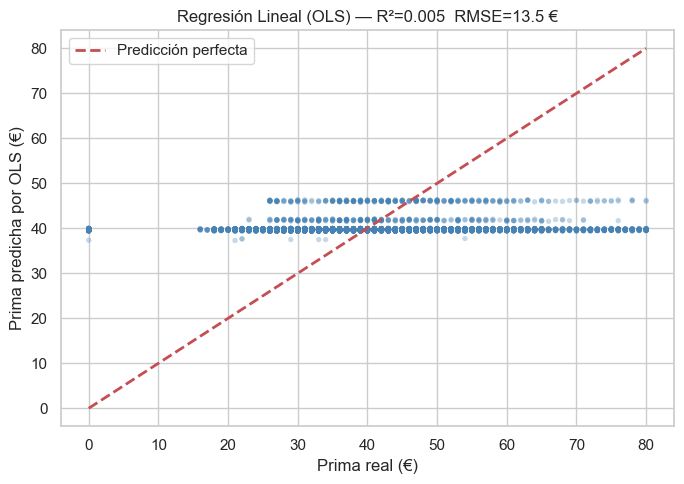

In [6]:
# Predicciones con OLS
y_pred_ols = X_b @ W_ols

# Cálculo manual de MSE y RMSE
mse_manual = np.mean((y_reg - y_pred_ols) ** 2)
rmse_manual = np.sqrt(mse_manual)

print(f'MSE  (manual): {mse_manual:.2f}')
print(f'RMSE (manual): {rmse_manual:.2f}  (el ruido añadido tenía σ=30, el modelo lo recupera bien)')
print(f'Media de PrimaEstimada: {y_reg.mean():.2f}  → error del {rmse_manual/y_reg.mean():.1%}')

# Scatter: valores reales vs predichos — debe seguir la diagonal
plt.figure(figsize=(7, 5))
plt.scatter(y_reg, y_pred_ols, alpha=0.3, color='steelblue', edgecolors='none', s=15)
mn, mx = y_reg.min(), y_reg.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Prima real (€)')
plt.ylabel('Prima predicha por OLS (€)')
plt.title(f'Regresión Lineal (OLS) — R²={1 - mse_manual/y_reg.var():.3f}  RMSE={rmse_manual:.1f} €')
plt.legend()
plt.tight_layout()
plt.show()

## 1.4 Descenso del Gradiente — Implementación desde cero

En lugar de la solución analítica, podemos encontrar los parámetros iterativamente:

$$\theta := \theta - \alpha \cdot \nabla_\theta J(\theta)$$

Donde el gradiente del MSE respecto a W es:

$$\nabla_W J = -\frac{2}{n} X^T (Y - X W)$$

El **learning rate** $\alpha$ controla el tamaño del paso.

MSE final (Gradient Descent): 181.1405
RMSE final:                   13.4588


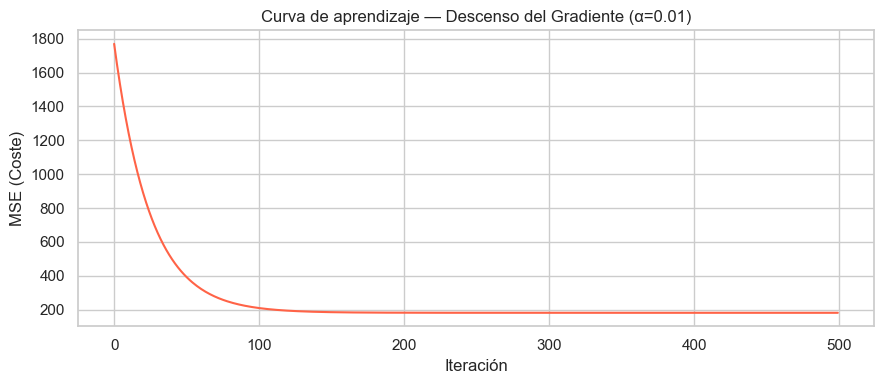

In [7]:
# Normalización de features para que el gradiente converja bien
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)
X_b_scaled = np.column_stack([np.ones(len(X_scaled)), X_scaled])

# Parámetros del algoritmo
alpha = 0.01       # learning rate
n_iter = 500       # número de iteraciones
n = len(y_reg)

# Inicialización aleatoria de W
np.random.seed(42)
W_gd = np.random.randn(X_b_scaled.shape[1]) * 0.01
cost_history = []

for i in range(n_iter):
    y_hat = X_b_scaled @ W_gd
    error = y_hat - y_reg
    
    # Gradiente: dJ/dW = (2/n) * X^T * error
    gradient = (2 / n) * X_b_scaled.T @ error
    
    # Actualización de parámetros
    W_gd = W_gd - alpha * gradient
    
    # Guardar coste (MSE)
    cost_history.append(np.mean(error ** 2))

print(f'MSE final (Gradient Descent): {cost_history[-1]:.4f}')
print(f'RMSE final:                   {np.sqrt(cost_history[-1]):.4f}')

# Curva de aprendizaje
plt.figure(figsize=(9, 4))
plt.plot(cost_history, color='tomato')
plt.xlabel('Iteración')
plt.ylabel('MSE (Coste)')
plt.title(f'Curva de aprendizaje — Descenso del Gradiente (α={alpha})')
plt.tight_layout()
plt.show()

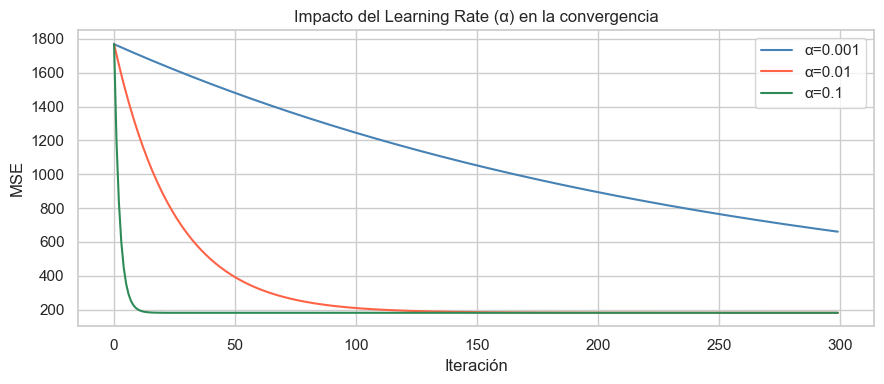

In [8]:
# Comparación de distintos learning rates
alphas = [0.001, 0.01, 0.1]
colors = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(9, 4))
for a, c in zip(alphas, colors):
    W = np.random.randn(X_b_scaled.shape[1]) * 0.01
    costs = []
    for _ in range(300):
        y_hat = X_b_scaled @ W
        error = y_hat - y_reg
        W = W - (2 * a / n) * X_b_scaled.T @ error
        costs.append(np.mean(error ** 2))
    plt.plot(costs, label=f'α={a}', color=c)

plt.xlabel('Iteración')
plt.ylabel('MSE')
plt.title('Impacto del Learning Rate (α) en la convergencia')
plt.legend()
plt.tight_layout()
plt.show()

---
# PARTE 2 — Probabilidad y Naive Bayes
---

## 2.1 Probabilidad clásica y frecuentista en el dataset

Calculamos probabilidades directamente sobre los datos observados.

In [9]:
# Probabilidades marginales
P_fraud = df['FraudFound_P'].mean()
P_no_fraud = 1 - P_fraud
P_police = (df['PoliceReportFiled'] == 'Yes').mean()
P_witness = (df['WitnessPresent'] == 'Yes').mean()

print('=== Probabilidades Marginales ===')
print(f'P(Fraude)           = {P_fraud:.4f} ({P_fraud:.2%})')
print(f'P(No Fraude)        = {P_no_fraud:.4f} ({P_no_fraud:.2%})')
print(f'P(Informe policial) = {P_police:.4f} ({P_police:.2%})')
print(f'P(Testigo presente) = {P_witness:.4f} ({P_witness:.2%})')

# Probabilidades condicionales P(Fraude | Testigo)
P_fraud_given_witness = df[df['WitnessPresent'] == 'Yes']['FraudFound_P'].mean()
P_fraud_given_no_witness = df[df['WitnessPresent'] == 'No']['FraudFound_P'].mean()

print('\n=== Probabilidades Condicionales ===')
print(f'P(Fraude | Testigo=Sí) = {P_fraud_given_witness:.4f} ({P_fraud_given_witness:.2%})')
print(f'P(Fraude | Testigo=No) = {P_fraud_given_no_witness:.4f} ({P_fraud_given_no_witness:.2%})')

=== Probabilidades Marginales ===
P(Fraude)           = 0.0599 (5.99%)
P(No Fraude)        = 0.9401 (94.01%)
P(Informe policial) = 0.0278 (2.78%)
P(Testigo presente) = 0.0056 (0.56%)

=== Probabilidades Condicionales ===
P(Fraude | Testigo=Sí) = 0.0345 (3.45%)
P(Fraude | Testigo=No) = 0.0600 (6.00%)


## 2.2 Distribuciones de Variables Aleatorias

Analizamos variables discretas y continuas del dataset y las comparamos con distribuciones teóricas.

- **Variable continua** (Age) → comparamos con distribución Normal
- **Variable discreta** (WeekOfMonth) → comparamos con distribución Uniforme discreta

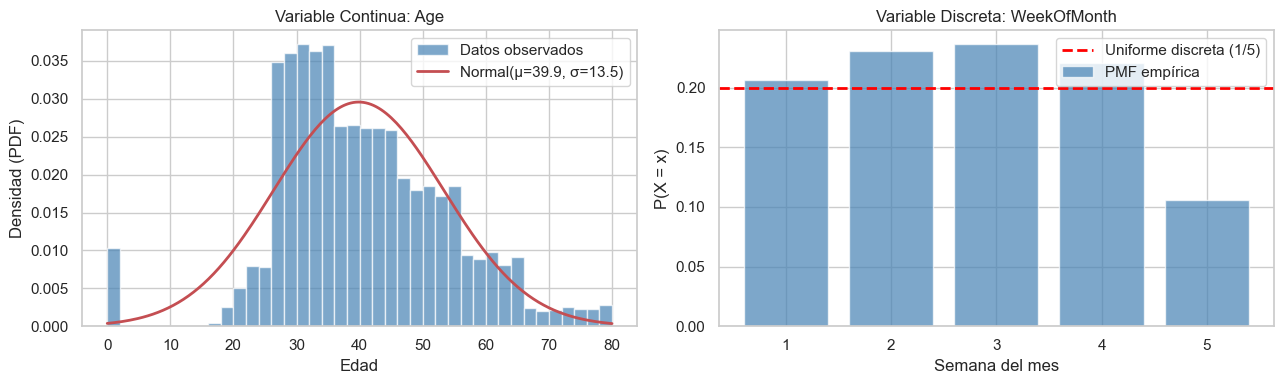

Age → E[X] = 39.86, Var[X] = 182.03, σ = 13.49


In [10]:
from scipy import stats

age = df['Age'].values
mu, sigma = age.mean(), age.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Variable continua: Age vs Normal ---
axes[0].hist(age, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='Datos observados')
x = np.linspace(age.min(), age.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
axes[0].set_title('Variable Continua: Age')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Densidad (PDF)')
axes[0].legend()

# --- Variable discreta: WeekOfMonth ---
week_counts = df['WeekOfMonth'].value_counts().sort_index()
week_freq = week_counts / week_counts.sum()  # PMF empírica
axes[1].bar(week_freq.index, week_freq.values, color='steelblue', alpha=0.7, label='PMF empírica')
axes[1].axhline(1/5, color='red', linestyle='--', lw=2, label='Uniforme discreta (1/5)')
axes[1].set_title('Variable Discreta: WeekOfMonth')
axes[1].set_xlabel('Semana del mes')
axes[1].set_ylabel('P(X = x)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticos
print(f'Age → E[X] = {mu:.2f}, Var[X] = {sigma**2:.2f}, σ = {sigma:.2f}')

## 2.3 Distribución de Fraude por categorías — Probabilidades condicionales visualizadas

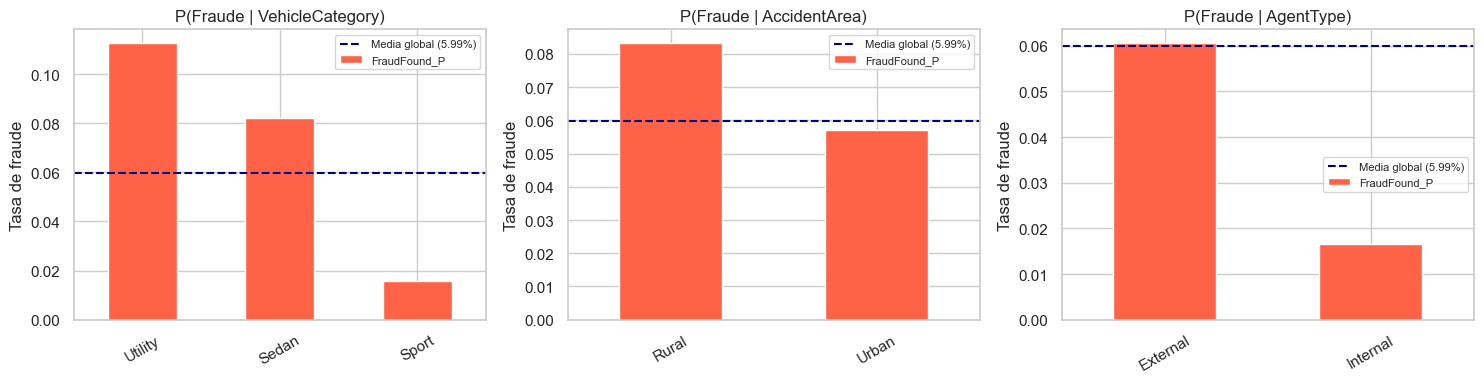

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_vars = ['VehicleCategory', 'AccidentArea', 'AgentType']
for ax, var in zip(axes, cat_vars):
    fraud_rate = df.groupby(var)['FraudFound_P'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.axhline(P_fraud, color='navy', linestyle='--', label=f'Media global ({P_fraud:.2%})')
    ax.set_title(f'P(Fraude | {var})')
    ax.set_ylabel('Tasa de fraude')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2.4 Teorema de Bayes — Aplicado manualmente

El Teorema de Bayes nos dice cómo actualizar nuestra creencia de fraude dado que observamos evidencia:

$$P(\text{Fraude} \mid \text{evidencia}) = \frac{P(\text{evidencia} \mid \text{Fraude}) \cdot P(\text{Fraude})}{P(\text{evidencia})}$$

In [12]:
# Calculamos P(Fraude | PoliceReport=No, WitnessPresent=No)
# usando el Teorema de Bayes de forma manual

fraud = df[df['FraudFound_P'] == 1]
no_fraud = df[df['FraudFound_P'] == 0]

# Prior
p_fraud = len(fraud) / len(df)
p_no_fraud = len(no_fraud) / len(df)

# Likelihoods P(evidencia | clase)
p_no_police_given_fraud = (fraud['PoliceReportFiled'] == 'No').mean()
p_no_police_given_no_fraud = (no_fraud['PoliceReportFiled'] == 'No').mean()
p_no_witness_given_fraud = (fraud['WitnessPresent'] == 'No').mean()
p_no_witness_given_no_fraud = (no_fraud['WitnessPresent'] == 'No').mean()

# Naive Bayes: asumimos independencia condicional
p_evidence_given_fraud = p_no_police_given_fraud * p_no_witness_given_fraud
p_evidence_given_no_fraud = p_no_police_given_no_fraud * p_no_witness_given_no_fraud

# P(evidencia) por la regla de la probabilidad total
p_evidence = p_evidence_given_fraud * p_fraud + p_evidence_given_no_fraud * p_no_fraud

# Posterior
p_fraud_given_evidence = (p_evidence_given_fraud * p_fraud) / p_evidence

print('=== Teorema de Bayes — Cálculo Manual ===')
print(f'Prior P(Fraude)                         = {p_fraud:.4f}')
print(f'P(SinPolicia | Fraude)                  = {p_no_police_given_fraud:.4f}')
print(f'P(SinTestigo | Fraude)                  = {p_no_witness_given_fraud:.4f}')
print(f'P(evidencia | Fraude)                   = {p_evidence_given_fraud:.4f}')
print(f'P(evidencia | No Fraude)                = {p_evidence_given_no_fraud:.4f}')
print(f'P(evidencia)                            = {p_evidence:.4f}')
print(f'\nPosterior P(Fraude | SinPolicia, SinTestigo) = {p_fraud_given_evidence:.4f} ({p_fraud_given_evidence:.2%})')
print(f'→ Con esta evidencia el riesgo de fraude es {p_fraud_given_evidence/p_fraud:.1f}x el prior')

=== Teorema de Bayes — Cálculo Manual ===
Prior P(Fraude)                         = 0.0599
P(SinPolicia | Fraude)                  = 0.9827
P(SinTestigo | Fraude)                  = 0.9967
P(evidencia | Fraude)                   = 0.9795
P(evidencia | No Fraude)                = 0.9660
P(evidencia)                            = 0.9668

Posterior P(Fraude | SinPolicia, SinTestigo) = 0.0606 (6.06%)
→ Con esta evidencia el riesgo de fraude es 1.0x el prior


## 2.5 Naive Bayes con scikit-learn — Clasificador de Fraude

**Naive Bayes** asume independencia condicional entre features dado el target:

$$P(y \mid x_1, \ldots, x_n) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

Usaremos:
- **GaussianNB** para features continuas
- **BernoulliNB** para features binarias

In [13]:
# Preprocesamiento: codificación de variables categóricas
df_model = df.copy()

cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features y target
feature_cols = [c for c in df_model.columns if c not in ['FraudFound_P', 'PolicyNumber']]
X = df_model[feature_cols].values
y = df_model['FraudFound_P'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Fraude en train: {y_train.mean():.2%} | en test: {y_test.mean():.2%}')

Train: (12336, 31), Test: (3084, 31)
Fraude en train: 5.98% | en test: 6.00%


In [14]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

print('=== Gaussian Naive Bayes ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_gnb, target_names=['No Fraude', 'Fraude']))

=== Gaussian Naive Bayes ===
Accuracy: 0.8492

Classification Report:
              precision    recall  f1-score   support

   No Fraude       0.95      0.88      0.92      2899
      Fraude       0.16      0.34      0.21       185

    accuracy                           0.85      3084
   macro avg       0.55      0.61      0.56      3084
weighted avg       0.91      0.85      0.87      3084



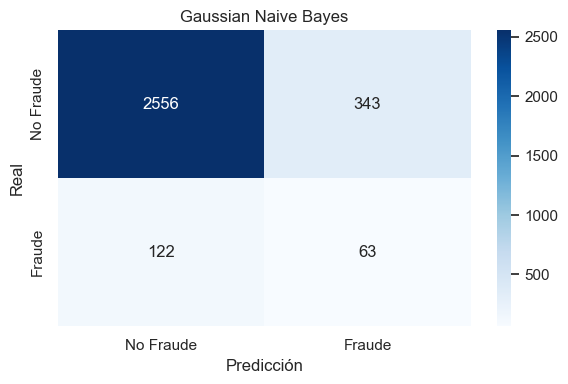

In [15]:
# Matrices de confusión comparativas
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
axes.set_title('Gaussian Naive Bayes')
axes.set_xlabel('Predicción')
axes.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 2.6 Probabilidades a posteriori del clasificador

Una ventaja de Naive Bayes es que devuelve **probabilidades calibradas** directamente. Esto es clave en detección de fraude: podemos usar un umbral de decisión distinto de 0.5.

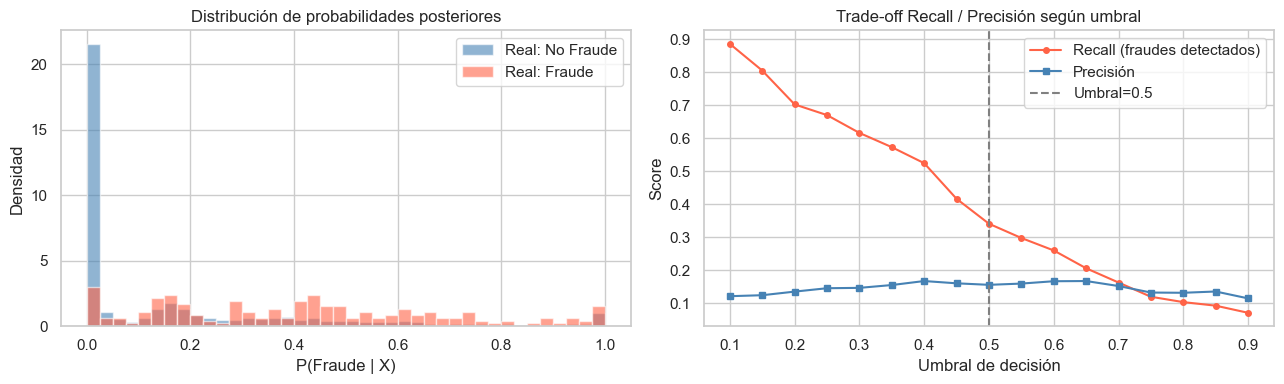

In [16]:
# Probabilidades a posteriori P(Fraude | X)
proba_gnb = gnb.predict_proba(X_test)[:, 1]  # P(Fraude=1 | X)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de probabilidades por clase real
axes[0].hist(proba_gnb[y_test == 0], bins=40, alpha=0.6, color='steelblue', label='Real: No Fraude', density=True)
axes[0].hist(proba_gnb[y_test == 1], bins=40, alpha=0.6, color='tomato', label='Real: Fraude', density=True)
axes[0].set_xlabel('P(Fraude | X)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de probabilidades posteriores')
axes[0].legend()

# Impacto del umbral de decisión en recall
thresholds = np.arange(0.1, 0.95, 0.05)
recalls, precisions = [], []
for t in thresholds:
    y_hat = (proba_gnb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat, labels=[0, 1]).ravel()
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

axes[1].plot(thresholds, recalls, 'tomato', marker='o', markersize=4, label='Recall (fraudes detectados)')
axes[1].plot(thresholds, precisions, 'steelblue', marker='s', markersize=4, label='Precisión')
axes[1].axvline(0.5, color='grey', linestyle='--', label='Umbral=0.5')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('Score')
axes[1].set_title('Trade-off Recall / Precisión según umbral')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Resumen de conceptos practicados

| Concepto (Tema 3) | Aplicación en el notebook |
|---|---|
| Modelo = Datos + Parámetros + Error | OLS sobre `Age` (caso real, R²≈0) y `PrimaEstimada` (sintético, R²≈1) |
| Solución OLS: $W=(X^TX)^{-1}X^TY$ | Implementación manual con NumPy, comparación coeficientes reales vs aprendidos |
| Función de coste MSE / RMSE | Cálculo manual en ambos casos |
| Descenso del Gradiente $\theta := \theta - \alpha \nabla J$ | Implementación iterativa sobre `PrimaEstimada`, curva de aprendizaje |
| Efecto del Learning Rate $\alpha$ | Comparación visual de convergencias (α=0.001 / 0.01 / 0.1) |
| Probabilidad frecuentista | $P(\text{Fraude})$, $P(\text{Fraude} \mid \text{Testigo})$ |
| Variables aleatorias — PDF / PMF | Age (continua, Normal) vs WeekOfMonth (discreta, Uniforme) |
| Teorema de Bayes | Cálculo manual de $P(\text{Fraude}\mid\text{SinPolicia, SinTestigo})$ |
| Naive Bayes (Gaussian) | Clasificador de fraude con scikit-learn |
| Probabilidades posteriores y umbral | Trade-off Recall/Precisión según umbral de decisión |